In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("penguins_lter.csv")

print(df.head())
print(df.shape)

  studyName  Sample Number                              Species  Region  \
0   PAL0708              1  Adelie Penguin (Pygoscelis adeliae)  Anvers   
1   PAL0708              2  Adelie Penguin (Pygoscelis adeliae)  Anvers   
2   PAL0708              3  Adelie Penguin (Pygoscelis adeliae)  Anvers   
3   PAL0708              4  Adelie Penguin (Pygoscelis adeliae)  Anvers   
4   PAL0708              5  Adelie Penguin (Pygoscelis adeliae)  Anvers   

      Island               Stage Individual ID Clutch Completion  Date Egg  \
0  Torgersen  Adult, 1 Egg Stage          N1A1               Yes  11/11/07   
1  Torgersen  Adult, 1 Egg Stage          N1A2               Yes  11/11/07   
2  Torgersen  Adult, 1 Egg Stage          N2A1               Yes  11/16/07   
3  Torgersen  Adult, 1 Egg Stage          N2A2               Yes  11/16/07   
4  Torgersen  Adult, 1 Egg Stage          N3A1               Yes  11/16/07   

   Culmen Length (mm)  Culmen Depth (mm)  Flipper Length (mm)  Body Mass (g)  \


In [3]:
print(df.dtypes)
print(df.isnull().sum())
print("dupli ",df.duplicated().sum())

studyName                  str
Sample Number            int64
Species                    str
Region                     str
Island                     str
Stage                      str
Individual ID              str
Clutch Completion          str
Date Egg                   str
Culmen Length (mm)     float64
Culmen Depth (mm)      float64
Flipper Length (mm)    float64
Body Mass (g)          float64
Sex                        str
Delta 15 N (o/oo)      float64
Delta 13 C (o/oo)      float64
Comments                   str
dtype: object
studyName                0
Sample Number            0
Species                  0
Region                   0
Island                   0
Stage                    0
Individual ID            0
Clutch Completion        0
Date Egg                 0
Culmen Length (mm)       2
Culmen Depth (mm)        2
Flipper Length (mm)      2
Body Mass (g)            2
Sex                     10
Delta 15 N (o/oo)       14
Delta 13 C (o/oo)       13
Comments               318


In [7]:
print("missing ")
print(df.isnull().sum())

missing 
studyName                0
Sample Number            0
Species                  0
Region                   0
Island                   0
Stage                    0
Individual ID            0
Clutch Completion        0
Date Egg                 0
Culmen Length (mm)       2
Culmen Depth (mm)        2
Flipper Length (mm)      2
Body Mass (g)            2
Sex                     10
Delta 15 N (o/oo)       14
Delta 13 C (o/oo)       13
Comments               318
dtype: int64


In [12]:
numeric_columns = [
    'Culmen Length (mm)',
    'Culmen Depth (mm)',
    'Flipper Length (mm)',
    'Body Mass (g)',
    'Delta 15 N (o/oo)',
    'Delta 13 C (o/oo)'
]
for col in numeric_columns:
    df[col] = df[col].fillna(df[col].median())

df['Sex'] = df['Sex'].fillna(df['Sex'].mode()[0])

In [ ]:
df.drop('Comments', axis=1, inplace=True)
print(df.columns)

Index(['studyName', 'Sample Number', 'Species', 'Region', 'Island', 'Stage',
       'Individual ID', 'Clutch Completion', 'Date Egg', 'Culmen Length (mm)',
       'Culmen Depth (mm)', 'Flipper Length (mm)', 'Body Mass (g)', 'Sex',
       'Delta 15 N (o/oo)', 'Delta 13 C (o/oo)'],
      dtype='str')


In [16]:
print(df.isnull().sum())

studyName              0
Sample Number          0
Species                0
Region                 0
Island                 0
Stage                  0
Individual ID          0
Clutch Completion      0
Date Egg               0
Culmen Length (mm)     0
Culmen Depth (mm)      0
Flipper Length (mm)    0
Body Mass (g)          0
Sex                    0
Delta 15 N (o/oo)      0
Delta 13 C (o/oo)      0
dtype: int64


In [18]:
print(df.describe())

       Sample Number  Culmen Length (mm)  Culmen Depth (mm)  \
count     344.000000          344.000000         344.000000   
mean       63.151163           43.925000          17.152035   
std        40.430199            5.443792           1.969060   
min         1.000000           32.100000          13.100000   
25%        29.000000           39.275000          15.600000   
50%        58.000000           44.450000          17.300000   
75%        95.250000           48.500000          18.700000   
max       152.000000           59.600000          21.500000   

       Flipper Length (mm)  Body Mass (g)  Delta 15 N (o/oo)  \
count           344.000000     344.000000         344.000000   
mean            200.892442    4200.872093           8.730086   
std              14.023826     799.696532           0.540630   
min             172.000000    2700.000000           7.632200   
25%             190.000000    3550.000000           8.307415   
50%             197.000000    4050.000000       

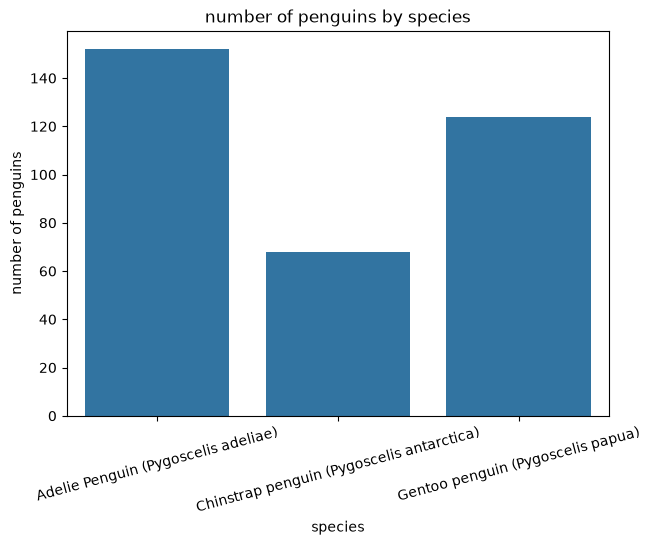

In [19]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x='Species')

plt.title("number of penguins by species")
plt.xlabel("species")
plt.ylabel("number of penguins")
plt.xticks(rotation=15)
plt.show()

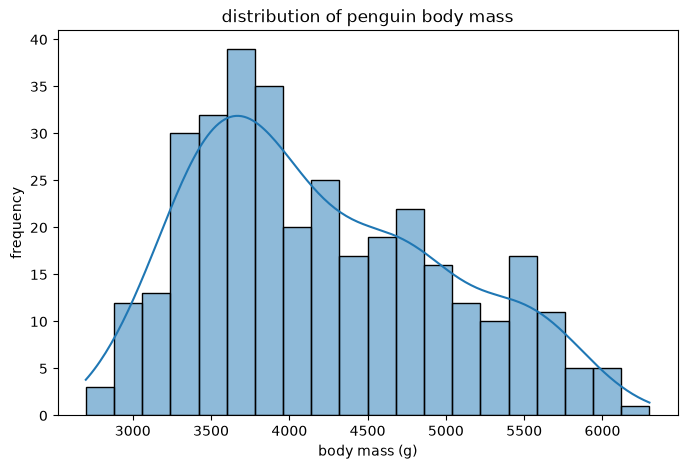

In [ ]:
plt.figure(figsize=(8, 5))

sns.histplot(df['Body Mass (g)'], bins=20, kde=True)

plt.title("distribution of penguin body mass")
plt.xlabel("body mass (g)")
plt.ylabel("frequency")
plt.show()

# Insight:
# The histogram shows the distribution of penguin body weights and whether most penguins fall within a particular weight range.

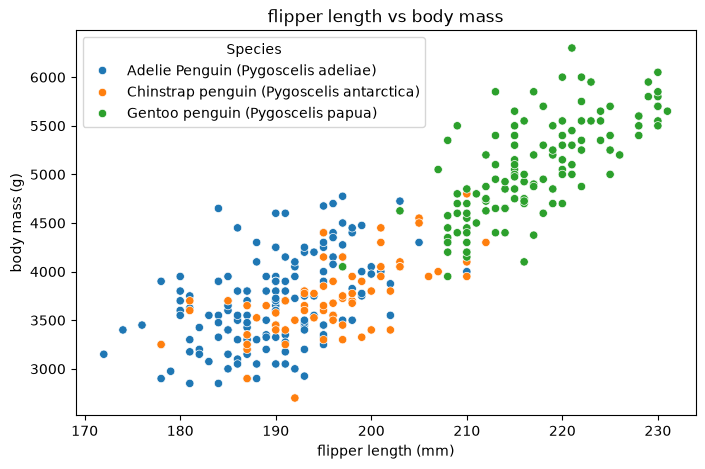

In [21]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='Flipper Length (mm)',
    y='Body Mass (g)',
    hue='Species'
)

plt.title("flipper length vs body mass")
plt.xlabel("flipper length (mm)")
plt.ylabel("body mass (g)")
plt.show()

# Insight:
# There is generally a positive relationship between flipper length and body mass. The species colors also help show differences between species.

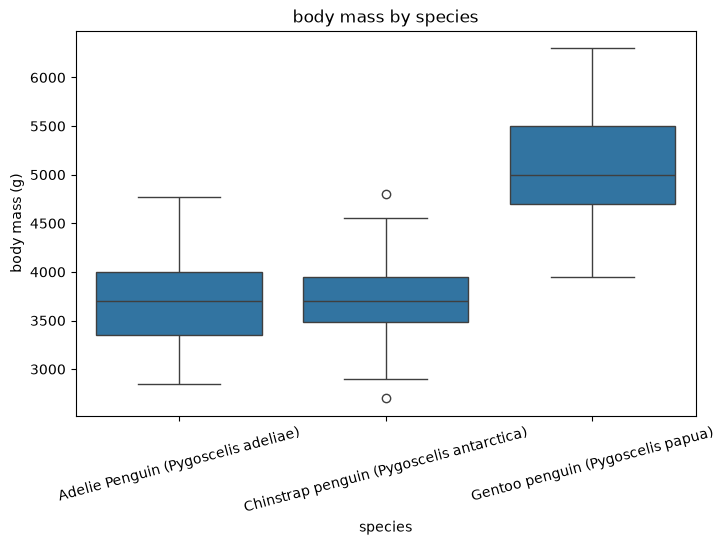

In [24]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='Species',
    y='Body Mass (g)'
)

plt.title("body mass by species")
plt.xlabel("species")
plt.ylabel("body mass (g)")
plt.xticks(rotation=15)
plt.show()

#Insight:
#The boxplot allows us to compare the body mass distributions of different penguin species and identify possible outliers.

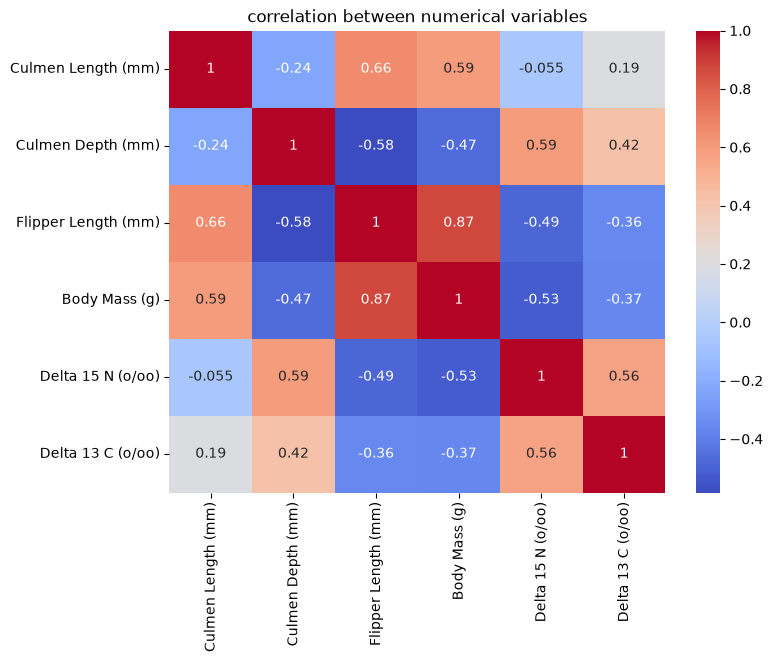

In [25]:
numeric_df = df[numeric_columns]

plt.figure(figsize=(8, 6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("correlation between numerical variables")
plt.show()

# Insight:
#The heatmap shows relationships between numerical features. For example, body mass and flipper length generally show a strong positive correlation.